# Laboratorio 6

## Avance de análisis exploratorio

Repositorio

https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio6

Este avance cubre la carga, la integración, la limpieza y el análisis exploratorio de los datos. También deja preparada la información que se usa para construir la red bipartita.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd()
if not (RAIZ / "scripts").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

from scripts.analisis_avance import (
    calcular_concentracion,
    diagnostico_atipicos,
    diagnostico_variables,
    efecto_limpieza,
    ejecutar_avance,
    graficar_barras,
    graficar_popularidad,
    popularidad_participacion,
    revisar_consistencia,
    resumen_componentes,
    resumen_numerico,
)

resultado = ejecutar_avance()
videos_originales = resultado["videos_originales"]
comentarios_originales = resultado["comentarios_originales"]
videos = resultado["videos"]
comentarios = resultado["comentarios"]
integrados = resultado["integrados"]
tablas = resultado["tablas"]
pd.set_option("display.max_colwidth", 80)

## 1. Carga, comprensión e integración

La unidad de observación de youtube_videos.csv es un video. Su llave primaria es video_id.

La unidad de observación de youtube_comments.csv es un comentario principal. Su llave primaria es comment_id y video_id funciona como llave foránea.

Un canal publica videos. Cada video tiene una categoría y fue recuperado por una consulta de búsqueda. Un autor publica un comentario en un video. El autor se identifica con author_channel_id. El canal dueño del video se identifica con channel_id. Los nombres y handles solo se usan como etiquetas visibles.

In [2]:
pd.DataFrame({
    "archivo": ["youtube_videos.csv", "youtube_comments.csv"],
    "filas": [videos_originales.shape[0], comentarios_originales.shape[0]],
    "columnas": [videos_originales.shape[1], comentarios_originales.shape[1]],
    "unidad": ["video", "comentario principal"],
    "llave_primaria": ["video_id", "comment_id"],
})

,archivo,filas,columnas,unidad,llave_primaria
0,youtube_videos.csv,293,20,video,video_id
1,youtube_comments.csv,406,17,comentario principal,comment_id


In [3]:
integrados["estado_union"].value_counts().rename_axis("estado").reset_index(name="comentarios")

,estado,comentarios
0,both,406
1,left_only,0
2,right_only,0


Los 406 comentarios se asociaron con un video. No quedó ningún comentario sin correspondencia.

## 2. Calidad, limpieza y preprocesamiento

El diagnóstico se hizo sobre los archivos originales. Los valores atípicos se identificaron con el rango intercuartílico. En variables de conteo, un valor atípico no se elimina de forma automática porque puede representar un video o comentario realmente popular.

In [4]:
display(diagnostico_variables(videos_originales))
display(diagnostico_variables(comentarios_originales))

,variable,tipo,faltantes,porcentaje_faltante,valores_unicos,constante
0,video_id,object,0,0.00,293,False
1,title,object,0,0.00,274,False
2,channel_name,object,0,0.00,97,False
3,channel_id,object,0,0.00,97,False
4,source_query,object,0,0.00,21,False
5,source_group,object,0,0.00,3,False
6,dataset_sources,object,0,0.00,23,False
7,channel_handle,object,0,0.00,97,False
8,published_time,object,13,4.44,80,False
9,view_count_text,object,13,4.44,259,False


,variable,tipo,faltantes,porcentaje_faltante,valores_unicos,constante
0,video_id,object,0,0.0,19,False
1,comment_id,object,0,0.0,406,False
2,video_title,object,0,0.0,19,False
3,channel_name,object,0,0.0,8,False
4,channel_id,object,0,0.0,8,False
5,author_name,object,0,0.0,332,False
6,author_channel_id,object,0,0.0,332,False
7,text,object,0,0.0,404,False
8,source_query,object,0,0.0,6,False
9,source_group,object,0,0.0,2,False


In [5]:
display(diagnostico_atipicos(videos))
display(diagnostico_atipicos(comentarios[["like_count", "reply_count"]]))
display(revisar_consistencia(videos, comentarios))

,variable,minimo,mediana,maximo,limite_inferior,limite_superior,cantidad_atipicos
0,view_count,2,1175.0,8190449,-10660.00,18340.00,49
1,view_count_desde_texto,2,1274.0,8190449,-11130.25,19123.75,49


,variable,minimo,mediana,maximo,limite_inferior,limite_superior,cantidad_atipicos
0,like_count,0,1.0,405,-3.0,5.0,48
1,reply_count,0,0.0,7,0.0,0.0,30


,revision,cantidad
0,video_id duplicado en videos,0
1,comment_id duplicado en comentarios,0
2,comentarios sin video asociado,0
3,channel_id distinto entre comentario y video,0
4,channel_id con varios nombres en videos,0
5,channel_id con varios handles en videos,0
6,nombre de canal ligado a varios channel_id,0
7,author_channel_id con varios nombres,0
8,registros con caracter de reemplazo en videos,1
9,registros con caracter de reemplazo en comentarios,0


### Variables que requieren cuidado

- viewer_rating está vacía en todos los comentarios y no se usa.
- is_pinned es constante y no ayuda a comparar comentarios.
- owner_handle repite channel_handle y upload_date coincide con publish_date.
- video_title, channel_name y channel_id aparecen en comentarios, pero se verifican contra la tabla de videos después de la unión.
- published_time y published_text son fechas relativas y no se convierten en fechas exactas.
- source_query explica cómo se encontró el contenido y no se interpreta como el tema definitivo.
- reply_count indica cuántas respuestas recibió un comentario, pero no dice quién respondió. No se usa para crear aristas entre autores.
- Los nombres y handles pueden cambiar. Los identificadores se mantienen como llaves.
- Un registro de videos contiene un carácter de reemplazo. Se conserva porque no se puede reconstruir con seguridad el carácter original.

### Conversión de conteos

Los espacios y separadores se eliminan antes de convertir los conteos. Las abreviaturas mil, k, millón y m se convierten con su multiplicador. Los valores vacíos o sin números se dejan como faltantes. Para los comentarios, los valores vacíos de me gusta se interpretan como cero porque el archivo usa el vacío para ese caso.

In [6]:
comparacion_vistas = videos[["view_count_text", "view_count", "view_count_desde_texto"]].copy()
pd.DataFrame({
    "medida": [
        "conteos de vistas convertidos",
        "conteos de vistas sin texto",
        "diferencias entre conteo numérico y texto",
        "conteos de me gusta convertidos",
    ],
    "cantidad": [
        comparacion_vistas["view_count_desde_texto"].notna().sum(),
        comparacion_vistas["view_count_desde_texto"].isna().sum(),
        comparacion_vistas.dropna()["view_count"].ne(comparacion_vistas.dropna()["view_count_desde_texto"]).sum(),
        comentarios["like_count"].notna().sum(),
    ],
})

,medida,cantidad
0,conteos de vistas convertidos,280
1,conteos de vistas sin texto,13
2,diferencias entre conteo numérico y texto,53
3,conteos de me gusta convertidos,406


### Limpieza de texto

Se conserva texto_original para auditoría y para análisis posteriores. texto_limpio se pasa a minúsculas. Se eliminan URL, menciones, puntuación, números, emojis y palabras vacías en español. En los hashtags se elimina el símbolo y se conserva la palabra. No se aplicó lematización porque el proyecto todavía no incluye un modelo de español validado y una regla simple podría cambiar nombres o palabras de manera incorrecta.

No se eliminaron registros por el resultado de la limpieza. Los textos vacíos se conservan para que el número de comentarios siga siendo auditable.

In [7]:
efecto_limpieza(comentarios)

,medida,cantidad
0,registros originales,406
1,registros eliminados,0
2,textos modificados,403
3,textos vacios antes,0
4,textos vacios despues,6
5,duplicados de texto antes,2
6,duplicados de texto despues,11


## 3. Análisis exploratorio

Los conteos siguientes describen la muestra disponible. No representan a toda la población de usuarios de YouTube ni a toda Guatemala.

In [8]:
pd.DataFrame({
    "medida": ["videos", "canales", "comentarios", "autores", "videos con comentarios"],
    "cantidad": [
        videos["video_id"].nunique(),
        videos["channel_id"].nunique(),
        comentarios["comment_id"].nunique(),
        comentarios["author_channel_id"].nunique(),
        comentarios["video_id"].nunique(),
    ],
})

,medida,cantidad
0,videos,293
1,canales,97
2,comentarios,406
3,autores,332
4,videos con comentarios,19


In [9]:
display(tablas["videos_canal"].head(10))
display(tablas["comentarios_video"].head(10))
display(tablas["comentarios_canal"].head(10))

,channel_id,channel_name,videos,visualizaciones
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32,56052
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27,452548
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18,31267
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17,424888
15,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14,141661
63,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11,4769
17,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11,5881
52,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10,2106
34,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10,329798
7,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8,1693


,video_id,comentarios,autores_unicos,title,channel_id,channel_name,view_count
246,n8iP75gIpmw,161,128,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,11775
229,j43HgwYFKfk,50,49,La cooptación de Walter Mazariegos en la USAC,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,10156
38,6W4u8sGEnGM,45,32,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,11670
130,OkXlHx0hx-8,25,18,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México...,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,14200
136,PjmxCj-a9Hg,25,19,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,3628
239,lj983NWyAQY,25,25,Plan 2032 Ciudad de Guatemala,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,304089
289,yLZS3JiEBg8,16,16,Arroz con pollo a la MONOPOLIO,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,1954
4,06mFNPU0aB8,14,13,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer ...,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,6692
250,ndAZjHqzzT8,12,10,Internet: escoger el menos malo,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,717
197,b_Hkrkl3adA,7,7,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rut...,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,5469


,channel_id,channel_name,comentarios,autores_unicos
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,214
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,50
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,18
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,25
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,13
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,7
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2


In [10]:
display(resumen_numerico(videos["view_count"], "visualizaciones"))
display(resumen_numerico(comentarios["reply_count"], "respuestas"))
display(resumen_numerico(comentarios["like_count"], "me gusta"))

,cantidad,media,desviacion,minimo,q1,mediana,q3,maximo
visualizaciones,293.0,60430.09,515798.31,2.0,215.0,1175.0,7465.0,8190449.0


,cantidad,media,desviacion,minimo,q1,mediana,q3,maximo
respuestas,406.0,0.13,0.58,0.0,0.0,0.0,0.0,7.0


,cantidad,media,desviacion,minimo,q1,mediana,q3,maximo
me gusta,406.0,5.73,30.66,0.0,0.0,1.0,2.0,405.0


In [11]:
display(tablas["categorias"])
display(tablas["consultas"].head(15))
display(tablas["hashtags"])
display(tablas["palabras"])
display(tablas["bigramas"])

,categoria,videos
0,News & Politics,138
1,People & Blogs,66
2,Entertainment,48
3,Education,19
4,Travel & Events,8
5,Science & Technology,6
6,Nonprofits & Activism,3
7,Film & Animation,2
8,Comedy,1
9,Sports,1


,consulta,videos
0,Municipalidad de Guatemala,20
1,Gobierno de Guatemala,18
2,@GobiernodelaRepublicadeGuatema,18
3,@GobiernodeGuatemala,17
4,guatemala noticias,16
5,Ministerio de Comunicaciones Guatemala,16
6,@MunicipalidaddeGuatemala-1551,16
7,Gobierno de la República de Guatemala,15
8,PMT Guatemala,15
9,Conred Guatemala,15


,hashtag,frecuencia
0,ineptobran,1


,palabra,frecuencia
0,pueblo,56
1,guatemala,52
2,dinero,34
3,solo,33
4,todos,33
5,presidente,32
6,país,31
7,trabajo,30
8,diputados,28
9,tienen,24


,bigrama,frecuencia
0,presidente bernardo,9
1,bernardo arevalo,8
2,ciudad guatemala,6
3,nery rodas,5
4,bla bla,5
5,pacto corruptos,5
6,viva guatemala,4
7,busquen trabajo,4
8,todos proyectos,4
9,sería bueno,4


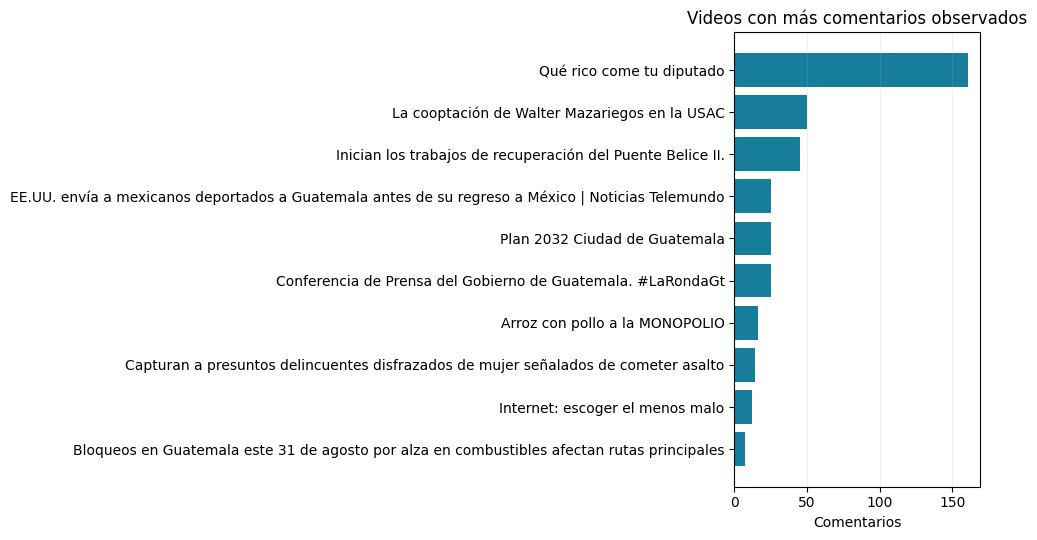

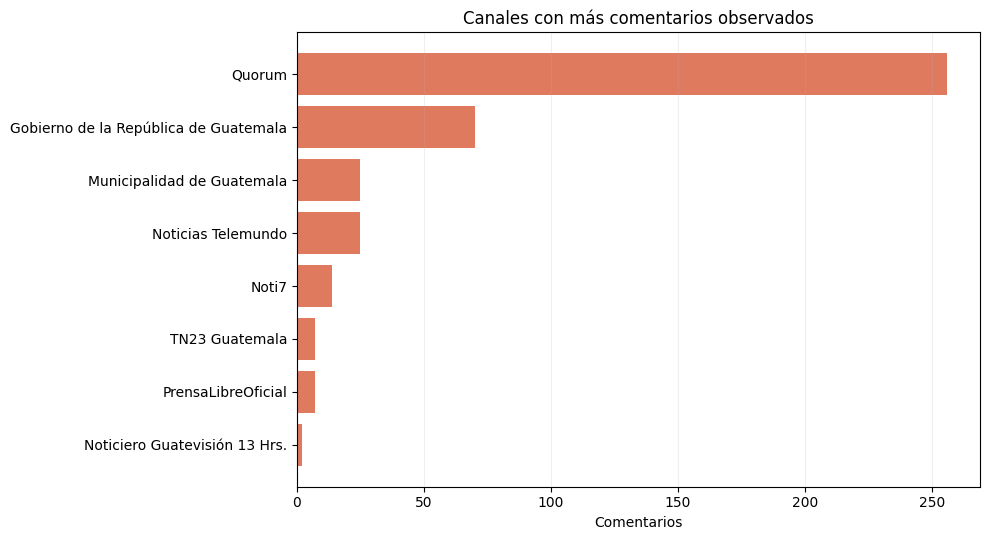

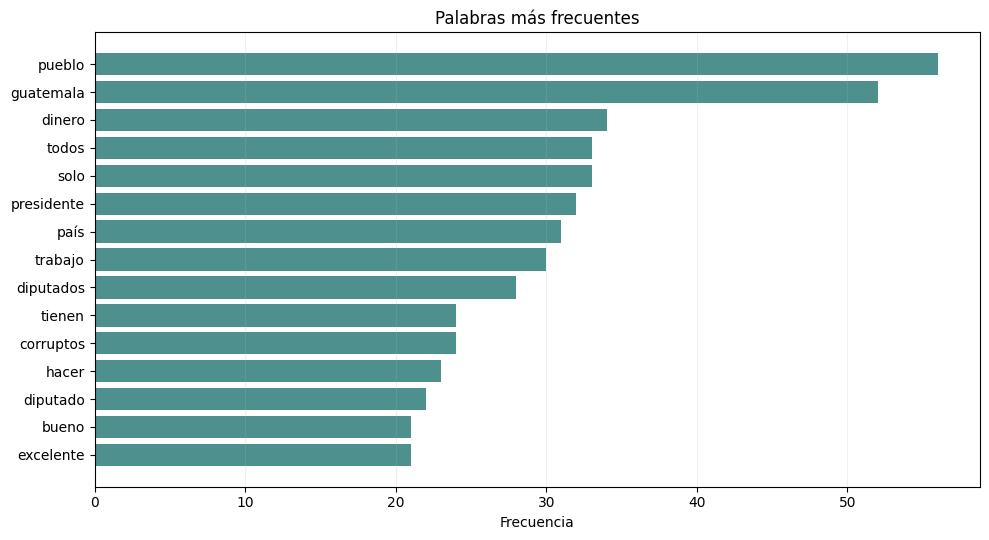

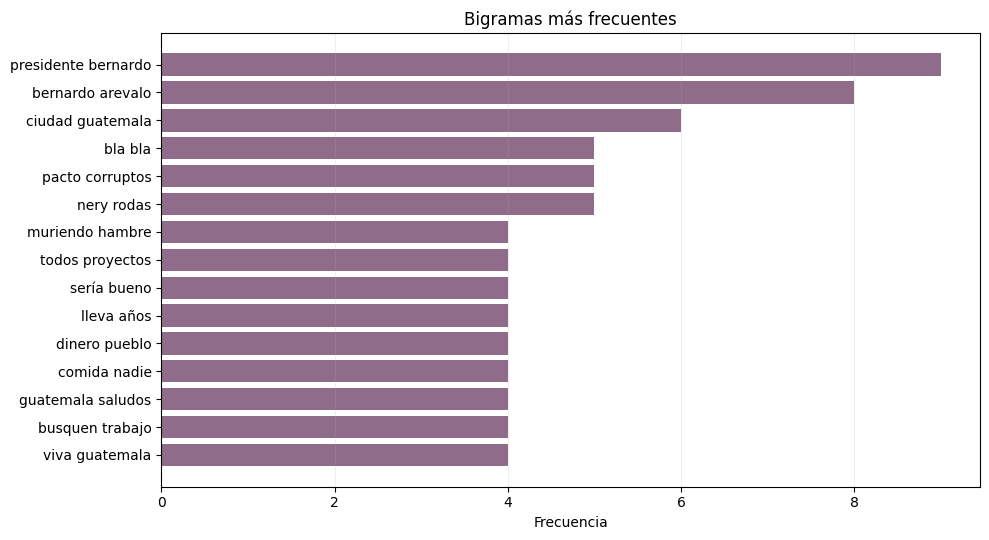

In [12]:
graficar_barras(tablas["comentarios_video"], "title", "comentarios", "Videos con más comentarios observados")
plt.show()
graficar_barras(tablas["comentarios_canal"], "channel_name", "comentarios", "Canales con más comentarios observados", cantidad=8, color="#E07A5F")
plt.show()
graficar_barras(tablas["palabras"], "palabra", "frecuencia", "Palabras más frecuentes", cantidad=15, color="#4D908E")
plt.show()
graficar_barras(tablas["bigramas"], "bigrama", "frecuencia", "Bigramas más frecuentes", cantidad=15, color="#8E6C8A")
plt.show()

### Concentración de la participación

In [13]:
concentracion_videos = calcular_concentracion(tablas["comentarios_video"], "comentarios", "videos")
concentracion_canales = calcular_concentracion(tablas["comentarios_canal"], "comentarios", "canales")
display(concentracion_videos)
display(concentracion_canales)

,unidad,grupo,cantidad_unidades,comentarios,porcentaje_comentarios
0,videos,principal,1,161,39.66
1,videos,cinco principales,5,306,75.37
2,videos,diez por ciento principal,30,406,100.00


,unidad,grupo,cantidad_unidades,comentarios,porcentaje_comentarios
0,canales,principal,1,256,63.05
1,canales,cinco principales,5,390,96.06
2,canales,diez por ciento principal,1,256,63.05


El video con más actividad reúne 39.66 por ciento de los comentarios. El canal con más actividad reúne 63.05 por ciento. La participación está muy concentrada.

### Popularidad y participación

,medida,valor
0,correlacion de Pearson,0.067
1,correlacion de Spearman,0.811
2,videos con comentarios,19.000


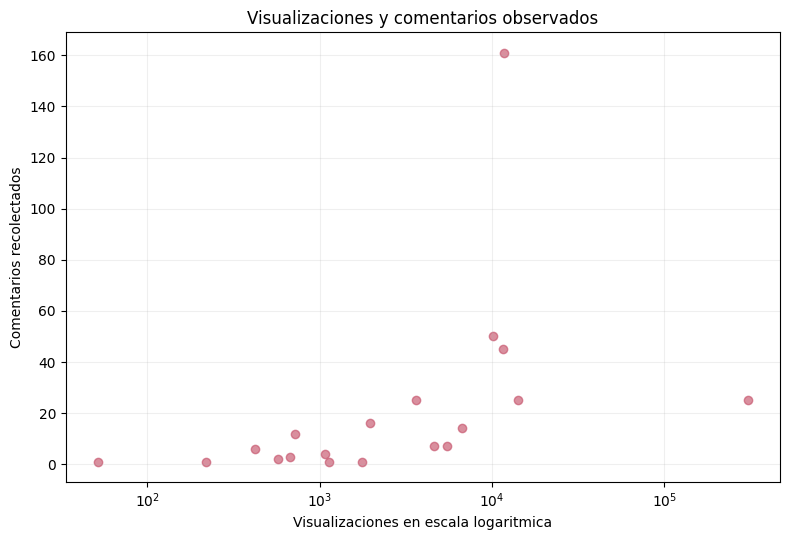

In [14]:
display(popularidad_participacion(tablas["comentarios_video"]))
graficar_popularidad(tablas["comentarios_video"])
plt.show()

La correlación de Pearson entre visualizaciones y comentarios es 0.067. La correlación de Spearman es 0.811. Esto muestra que el orden general puede ser parecido, pero la relación lineal es débil por la presencia de diferencias grandes entre videos. Solo se comparan los 19 videos con comentarios recolectados. Las visualizaciones y los comentarios son conteos observados en momentos y coberturas distintas.

### Respuestas a las preguntas obligatorias

#### Qué videos y canales concentran la mayor participación observada

El video con más comentarios es Qué rico come tu diputado, del canal Quorum. Tiene 161 comentarios y 128 autores únicos. El canal con más comentarios es Quorum, con 256 comentarios y 214 autores únicos.

#### Existen audiencias compartidas

Hay 9 autores que aparecen en más de un video y 4 autores que aparecen en más de un canal. El par con mayor cruce fue Internet: escoger el menos malo y Arroz con pollo a la MONOPOLIO, con 2 autores compartidos. Estos cruces muestran coparticipación observada, no amistad ni conversación directa.

#### Qué autores funcionan como puentes

Los primeros autores que aparecen como puntos de articulación son @inge_vergueta, @hashojea7348, @virgiliogarcia3039, @MarcosCarillo-b1r, @franciscoflores3120. Si se quita uno de estos nodos, aumenta la cantidad de partes desconectadas en la red observada. Esto no prueba influencia fuera de la muestra.

#### Qué temas y sentimientos caracterizan las principales comunidades

En este avance se usan componentes conectadas como una descripción preliminar. Todavía no se aplica un algoritmo de comunidades. La componente 1 tiene 276 autores, 10 videos y 343 comentarios. Sus palabras frecuentes son pueblo, dinero, presidente, solo, trabajo. El sentimiento principal es neutral con 72.89 por ciento. La componente 2 tiene 25 autores, 1 videos y 25 comentarios. Sus palabras frecuentes son guatemala, ciudad, saludos, todos, viva. El sentimiento principal es neutral con 84.0 por ciento. La componente 3 tiene 18 autores, 1 videos y 25 comentarios. Sus palabras frecuentes son you, usa, pais, otros, país. El sentimiento principal es neutral con 76.0 por ciento.

El análisis de sentimiento de este avance usa un léxico pequeño y transparente en español. Clasifica 73 comentarios como positivos, 34 como negativos y 299 como neutrales. Es un resultado preliminar y no detecta bien ironía, contexto ni negaciones.

#### La visibilidad coincide con la participación observada

No coincide de forma directa. El video con más visualizaciones dentro de los videos comentados es Los ALUCINANTES autobuses de Guatemala | "Burras", con 8190449 visualizaciones y 0 comentarios. El video con más comentarios tiene 11775 visualizaciones y 161 comentarios.

#### Qué conclusiones están limitadas por la recolección

Los comentarios solo cubren una parte de los videos. La selección depende de consultas y canales usados durante la recolección. Las fechas relativas no permiten reconstruir el momento exacto. Los conteos cambian con el tiempo. No se conoce quién respondió a quién. La concentración en pocos videos puede reflejar tanto participación real como diferencias en la cobertura.

### Preguntas adicionales

#### Qué parte de los videos tiene comentarios recolectados

Los comentarios cubren 19 de 293 videos. Esto equivale a 6.48 por ciento. El análisis de participación se limita a esa parte de la muestra.

#### La mayoría de autores participa en varios videos

No. 323 de 332 autores aparecen en un solo video. Solo 9 aparecen en más de uno. La audiencia observada es principalmente local a cada video.

#### Cuánta interacción adicional muestran las respuestas y los me gusta

Se observaron 51 respuestas distribuidas en 30 comentarios principales. Los comentarios recibieron 2325 me gusta en total. reply_count no permite saber quién respondió y por eso no agrega relaciones entre autores.

## Cierre del avance

La muestra tiene una participación muy concentrada en pocos videos y canales. La mayoría de autores aparece en un solo video. Existen algunos cruces de audiencia y puntos de articulación que se revisan con más detalle en el notebook de la red bipartita. Todas las conclusiones describen únicamente los datos recolectados.